# Eksplorasi Analisis & Prediksi Harga Pangan Menggunakan XGBoost
Notebook ini berisi alur lengkap proses analisis deret waktu (*time series*) dan pembuatan model prediksi menggunakan XGBoost untuk seluruh kategori komoditas pangan nasional berdasarkan data dari Bank Indonesia.

### Alur Pengerjaan:
1. **Data Collecting**: Mengambil data harga dari local dataset `dataset/commodity_history.json` untuk 10 kategori komoditas pangan.
2. **Exploratory Data Analysis (EDA)**: Menganalisis karakteristik data secara visual dan stasioneritas (ADF Test) untuk seluruh komoditas.
3. **Feature Engineering**: Membuat fitur lag (1, 2, 7, 30 hari), fitur tanggal (day of week, month, quarter, year), dan statistik bergulir (rolling mean & std) yang aman dari data leakage.
4. **Model Training (XGBoost)**: Melatih model XGBoost dengan parameter optimal yang diperoleh melalui penyetelan hyperparameter (GridSearchCV) menggunakan TimeSeriesSplit serta mengaktifkan early stopping untuk mencegah overfitting.
5. **Model Evaluation**: Mengevaluasi hasil prediksi menggunakan metrik evaluasi (MAE, RMSE, MAPE, R2) dan visualisasi terpisah untuk 4 komoditas kunci.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

# Menyembunyikan warning
warnings.filterwarnings('ignore')

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Data Collecting
Kami menggunakan data harian dari local dataset `dataset/commodity_history.json` untuk 10 kategori bahan pokok berikut:
- `cat_1` (Beras)
- `cat_2` (Daging Ayam)
- `cat_3` (Daging Sapi)
- `cat_4` (Telur Ayam)
- `cat_5` (Bawang Merah)
- `cat_6` (Bawang Putih)
- `cat_7` (Cabai Merah)
- `cat_8` (Cabai Rawit)
- `cat_9` (Minyak Goreng)
- `cat_10` (Gula Pasir)

Rentang waktu yang digunakan adalah dari 01 Januari 2024 hingga 24 Mei 2026. Untuk efisiensi, data disimpan ke cache file `raw_market_prices_cache.csv`.

In [2]:
# List kategori komoditas berdasarkan request
categories = {
    "cat_1": "Beras",
    "cat_2": "Daging Ayam",
    "cat_3": "Daging Sapi",
    "cat_4": "Telur Ayam",
    "cat_5": "Bawang Merah",
    "cat_6": "Bawang Putih",
    "cat_7": "Cabai Merah",
    "cat_8": "Cabai Rawit",
    "cat_9": "Minyak Goreng",
    "cat_10": "Gula Pasir"
}

json_path = "dataset/commodity_history.json"
cache_file = "raw_market_prices_cache.csv"

if os.path.exists(cache_file):
    print(f"Menemukan file cache lokal '{cache_file}'. Membaca data cache...")
    df_raw = pd.read_csv(cache_file)
else:
    import json
    print(f"Membaca data dari local dataset '{json_path}'...")
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"File dataset tidak ditemukan di: {json_path}")
        
    with open(json_path, "r", encoding="utf-8") as f:
        json_data = json.load(f)
        
    raw_data_list = []
    
    # Filter dan strukturkan data agar sesuai format wide dataframe sebelumnya
    for item in json_data["data"]:
        # Cek jika item di level 1 (kategori utama) dan namanya terdaftar di kategori kita
        if item.get("level") == 1 and item.get("name") in categories.values():
            cat_name = item.get("name")
            row_dict = {"Category": cat_name, "Subcategory": cat_name}
            
            # Ambil semua data tanggal (key format DD/MM/YYYY)
            for key, value in item.items():
                if "/" in key and len(key.split("/")) == 3:
                    row_dict[key] = value
                    
            raw_data_list.append(row_dict)
            print(f"Berhasil memuat data untuk: {cat_name}")
            
    df_raw = pd.DataFrame(raw_data_list)
    
    if not df_raw.empty:
        df_raw.to_csv(cache_file, index=False)
        print(f"Sukses menyimpan data ke cache file '{cache_file}'.")
    else:
        raise ValueError("Gagal memperoleh data dari dataset JSON. Periksa format data.")

print("\nDimensi data mentah:", df_raw.shape)
df_raw.head()

Membaca data dari local dataset 'dataset/commodity_history.json'...
Berhasil memuat data untuk: Beras
Berhasil memuat data untuk: Daging Ayam
Berhasil memuat data untuk: Daging Sapi
Berhasil memuat data untuk: Telur Ayam
Berhasil memuat data untuk: Bawang Merah
Berhasil memuat data untuk: Bawang Putih
Berhasil memuat data untuk: Cabai Merah
Berhasil memuat data untuk: Cabai Rawit
Berhasil memuat data untuk: Minyak Goreng
Berhasil memuat data untuk: Gula Pasir
Sukses menyimpan data ke cache file 'raw_market_prices_cache.csv'.

Dimensi data mentah: (10, 877)


,Category,Subcategory,01/01/2024,02/01/2024,03/01/2024,04/01/2024,05/01/2024,06/01/2024,07/01/2024,08/01/2024,...,15/05/2026,16/05/2026,17/05/2026,18/05/2026,19/05/2026,20/05/2026,21/05/2026,22/05/2026,23/05/2026,24/05/2026
0,Beras,Beras,"14,550","14,700","14,700","14,750","14,750","14,750","14,750","14,750",...,"16,000","15,650","15,650","16,000","16,000","16,000","16,000","16,000","15,650","15,650"
1,Daging Ayam,Daging Ayam,"36,950","37,550","37,650","37,650","37,650","37,650","37,650","37,400",...,"38,750","40,950","40,950","38,650","38,550","38,400","38,600","38,500","40,950","40,950"
2,Daging Sapi,Daging Sapi,"134,600","134,650","134,700","134,650","134,650","134,650","134,650","134,400",...,"144,200","138,350","138,350","144,400","144,400","144,550","144,700","144,800","138,350","138,350"
3,Telur Ayam,Telur Ayam,"28,850","29,350","29,250","29,200","29,150","29,150","29,150","28,950",...,"30,950","30,300","30,300","30,600","30,550","30,500","30,550","30,500","30,300","30,300"
4,Bawang Merah,Bawang Merah,"40,000","41,250","41,600","42,000","42,050","42,050","42,050","42,050",...,"47,400","46,300","46,300","47,500","47,650","47,950","48,100","48,350","46,300","46,300"


## 2. Exploratory Data Analysis (EDA)
Pada bagian ini, kita akan:
1. Mengubah bentuk data mentah (wide format) menjadi format panjang (long format/tidy data) agar mudah dianalisis dan dimodelkan.
2. Membersihkan nilai harga pangan (menghilangkan tanda koma pemisah ribuan dan mengonversi ke tipe data numerik).
3. Memvisualisasikan tren harga dari seluruh kategori komoditas pangan.
4. Melakukan uji stasioneritas menggunakan **Augmented Dickey-Fuller (ADF) Test** untuk seluruh komoditas guna mengetahui karakteristik tren.

In [3]:
# Transformasi dari Wide ke Long format
long_data = []

for idx, row in df_raw.iterrows():
    category = row["Category"]
    subcategory = row["Subcategory"]

    for col in df_raw.columns:
        if "/" in col:
            val_str = str(row[col]).strip()
            if val_str and val_str not in ["-", "null", "None", "nan"]:
                try:
                    price = float(val_str.replace(",", ""))
                    date_val = datetime.strptime(col, "%d/%m/%Y").date()
                    long_data.append({
                        "Date": date_val,
                        "Category": category,
                        "Subcategory": subcategory,
                        "Price": price
                    })
                except ValueError:
                    pass

df_tidy = pd.DataFrame(long_data)
df_tidy["Date"] = pd.to_datetime(df_tidy["Date"])
df_tidy = df_tidy.sort_values(by=["Category", "Date"]).reset_index(drop=True)

print("Dimensi data bersih:", df_tidy.shape)
print("\nStatistik Deskriptif Kategori:")
print(df_tidy.groupby("Category")["Price"].describe())

Dimensi data bersih: (8750, 4)

Statistik Deskriptif Kategori:
               count           mean           std       min       25%  \
Category                                                                
Bawang Merah   875.0   42836.000000   6673.455392   27750.0   39200.0   
Bawang Putih   875.0   42382.742857   2481.026264   38500.0   40400.0   
Beras          875.0   15525.028571    310.083908   14550.0   15300.0   
Cabai Merah    875.0   51370.571429   8747.132561   30950.0   46300.0   
Cabai Rawit    875.0   57478.742857  10254.213546   38800.0   50000.0   
Daging Ayam    875.0   37896.628571   2078.990072   34350.0   36150.0   
Daging Sapi    875.0  137122.514286   2770.477424  132050.0  135300.0   
Gula Pasir     875.0   18794.800000    432.032396   17700.0   18500.0   
Minyak Goreng  875.0   20389.542857   1032.593443   18700.0   19200.0   
Telur Ayam     875.0   30751.028571   1159.190751   28450.0   29850.0   

                    50%       75%       max  
Category      

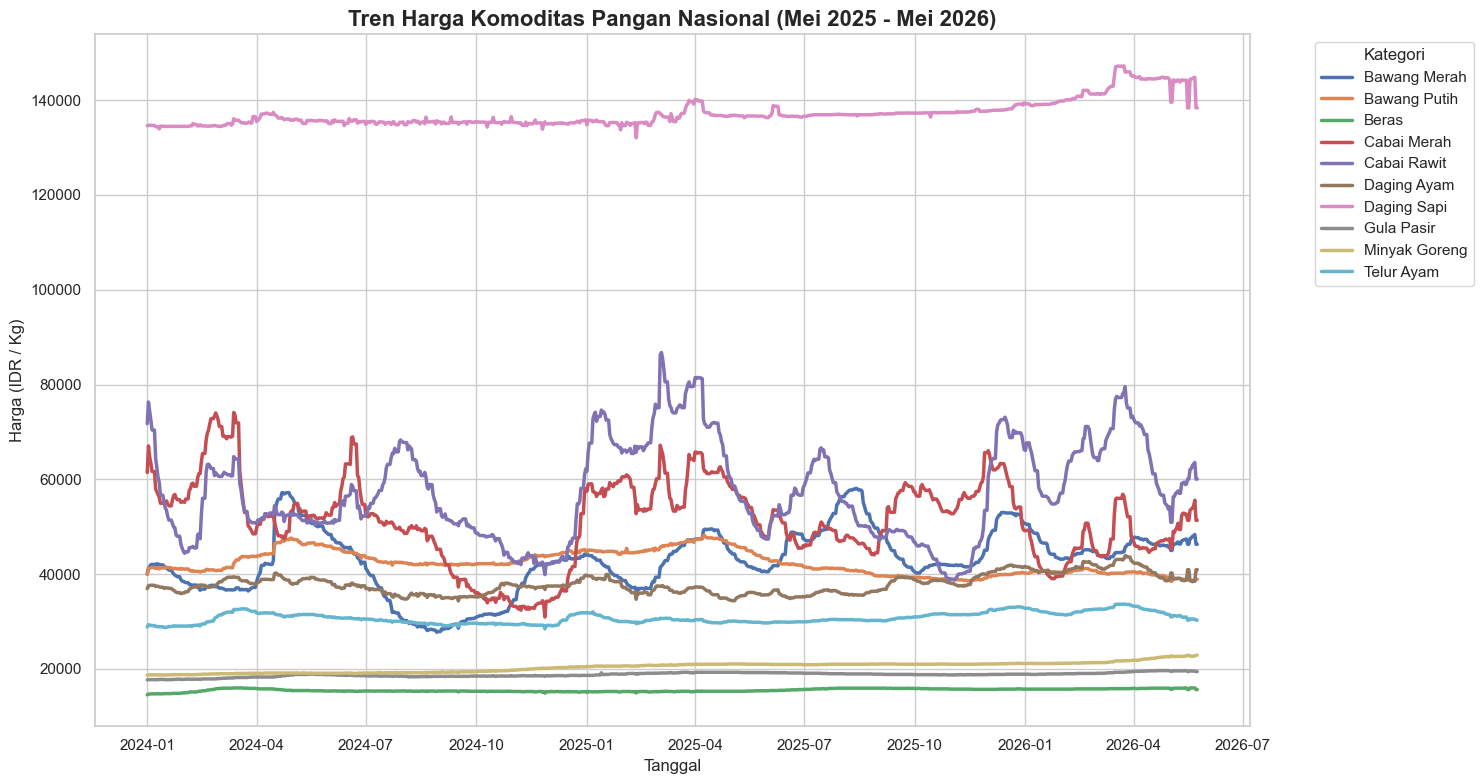

In [4]:
# Plot tren harga untuk seluruh kategori komoditas
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_tidy, x="Date", y="Price", hue="Category", linewidth=2.5)
plt.title("Tren Harga Komoditas Pangan Nasional (Mei 2025 - Mei 2026)", fontsize=16, fontweight='bold')
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Harga (IDR / Kg)", fontsize=12)
plt.legend(title="Kategori", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
# Uji Dickey-Fuller Stasioneritas untuk Seluruh Komoditas
adf_results = []

for cat_name in df_tidy["Category"].unique():
    df_cat = df_tidy[df_tidy["Category"] == cat_name].copy()
    df_cat = df_cat.set_index("Date").asfreq('D')
    # Imputasi sementara untuk uji ADF (jika ada nilai kosong)
    price_series = df_cat["Price"].interpolate(method='linear').ffill().bfill()
    
    result = adfuller(price_series)
    adf_results.append({
        "Category": cat_name,
        "ADF Statistic": round(result[0], 4),
        "p-value": round(result[1], 4),
        "Is Stationary": "Stasioner" if result[1] < 0.05 else "TIDAK Stasioner"
    })

df_adf_summary = pd.DataFrame(adf_results)
print("Ringkasan Uji Stasioneritas ADF untuk Seluruh Komoditas:")
df_adf_summary

Ringkasan Uji Stasioneritas ADF untuk Seluruh Komoditas:


,Category,ADF Statistic,p-value,Is Stationary
0,Bawang Merah,-3.4247,0.0101,Stasioner
1,Bawang Putih,-1.7060,0.4280,TIDAK Stasioner
2,Beras,-3.5817,0.0061,Stasioner
3,Cabai Merah,-2.9270,0.0423,Stasioner
4,Cabai Rawit,-3.6653,0.0046,Stasioner
5,Daging Ayam,-1.8439,0.3589,TIDAK Stasioner
6,Daging Sapi,-0.6162,0.8673,TIDAK Stasioner
7,Gula Pasir,-2.4764,0.1213,TIDAK Stasioner
8,Minyak Goreng,0.7003,0.9898,TIDAK Stasioner
9,Telur Ayam,-3.2779,0.0159,Stasioner


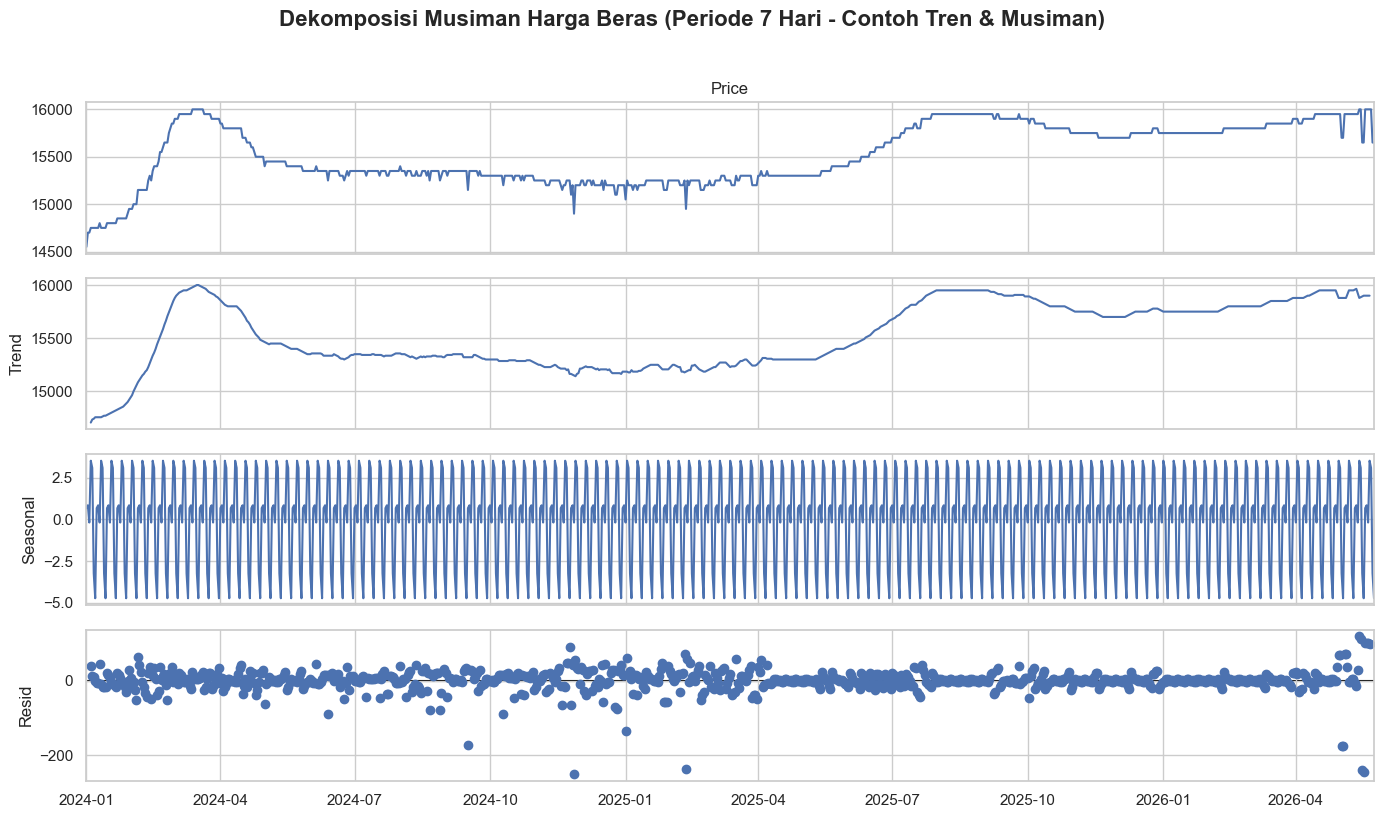

In [6]:
# Dekomposisi Musiman Harga Beras (sebagai contoh visualisasi tren & musiman)
df_beras_demo = df_tidy[df_tidy["Category"] == "Beras"].copy()
df_beras_demo = df_beras_demo.set_index("Date").asfreq('D')
df_beras_demo["Price"] = df_beras_demo["Price"].interpolate(method='linear').ffill().bfill()

decomposition = seasonal_decompose(df_beras_demo["Price"], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Dekomposisi Musiman Harga Beras (Periode 7 Hari - Contoh Tren & Musiman)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Modeling Pipeline
Pada bagian ini, kita akan:
1. **Feature Engineering**: Membuat fitur-fitur yang diperlukan oleh model XGBoost (karena model pohon keputusan tidak memiliki pemahaman intrinsik tentang urutan waktu):
   - **Fitur Tanggal**: Hari dalam seminggu, bulan, kuartal, tahun.
   - **Fitur Lag**: Nilai harga pada t-1, t-2, t-7, dan t-30 hari sebelumnya untuk menangkap autokorelasi.
   - **Statistik Bergulir (Rolling Statistics)**: Rata-rata (mean) dan standar deviasi bergulir selama 7 hari terakhir dari nilai harga yang telah di-shift 1 hari sebelumnya (guna mencegah data leakage).
2. **Temporal Train/Test Split**: Pembagian data latih dan uji secara kronologis (80% latih, 20% uji) tanpa pengacakan (no shuffle) untuk mencegah data leakage masa depan ke masa lalu.
3. **Hyperparameter Tuning & Training**: Pencarian parameter terbaik menggunakan GridSearchCV dengan skema **TimeSeriesSplit** untuk meminimalkan RMSE pada data validasi temporal.
4. **Early Stopping**: Menggunakan data evaluasi temporal untuk menghentikan iterasi boosting ketika performa tidak lagi meningkat pada set validasi, mencegah overfitting.

In [7]:
def create_features(df, target_col='Price'):
    """
    Membuat fitur temporal untuk time series forecasting.
    Menggunakan shift untuk menghindari data leakage pada rolling statistics.
    """
    df = df.copy()
    
    # 1. Fitur Tanggal (Datetime)
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    
    # 2. Fitur Lag (Nilai harga masa lalu)
    for lag in [1, 2, 7, 30]:
        df[f'lag_{lag}'] = df[target_col].shift(lag)
        
    # 3. Statistik Bergulir (Rolling Statistics)
    # Lakukan shift(1) terlebih dahulu sebelum rolling untuk menghindari leakage dari hari t
    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()
    df['rolling_mean_30'] = df[target_col].shift(1).rolling(window=30).mean()
    
    # Hapus baris dengan nilai NaN akibat shift/rolling
    df = df.dropna()
    return df

def preprocess_data(df_cat, train_ratio=0.8):
    """
    Melakukan interpolasi data yang hilang, feature engineering, 
    dan pembagian data secara kronologis (Temporal Split).
    """
    df_cat = df_cat.copy()
    # Mengisi data kosong jika ada
    df_cat['Price'] = df_cat['Price'].interpolate(method='linear').ffill().bfill()
    
    # Membuat fitur temporal
    df_feat = create_features(df_cat)
    
    # Split data secara kronologis (Temporal Split)
    split_idx = int(len(df_feat) * train_ratio)
    train_df = df_feat.iloc[:split_idx]
    test_df = df_feat.iloc[split_idx:]
    
    return train_df, test_df

def train_xgboost_model(X_train, y_train, X_val, y_val):
    """
    Melatih model XGBoost dengan hyperparameter tuning menggunakan TimeSeriesSplit
    dan early stopping pada data validasi.
    """
    param_grid = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.03, 0.1],
        'n_estimators': [100, 300],
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    }
    
    xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
    
    # Menggunakan TimeSeriesSplit untuk cross-validation temporal
    tscv = TimeSeriesSplit(n_splits=3)
    
    grid_search = GridSearchCV(
        estimator=xgb_reg,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
    # Melatih kembali model terbaik dengan early stopping menggunakan set validasi
    best_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    return best_model, grid_search.best_params_

def evaluate_predictions(y_true, y_pred):
    """
    Menghitung metrik MAE, RMSE, MAPE, dan R2 Score.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2 Score": r2
    }

In [8]:
# Eksekusi Loop Pelatihan Model XGBoost untuk Seluruh Komoditas
all_metrics = []
predictions_dict = {}
best_params_dict = {}

# Daftar kolom fitur yang digunakan untuk pemodelan
feature_cols = [
    'dayofweek', 'month', 'quarter', 'year', 'dayofyear',
    'lag_1', 'lag_2', 'lag_7', 'lag_30',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30'
]

for cat_id, cat_name in categories.items():
    print(f"Memproses {cat_name}...")
    df_cat = df_tidy[df_tidy["Category"] == cat_name].copy()
    if df_cat.empty:
        print(f"  Peringatan: Data untuk {cat_name} tidak ditemukan.")
        continue
        
    df_cat = df_cat.set_index("Date").asfreq('D')
    
    # Preprocessing & split data secara kronologis (80% Train, 20% Test)
    train_df, test_df = preprocess_data(df_cat, train_ratio=0.8)
    
    # Bagi train_df menjadi train_fit (85% dari train) dan validation (15% dari train) untuk early stopping
    val_ratio = 0.15
    val_split_idx = int(len(train_df) * (1 - val_ratio))
    train_fit = train_df.iloc[:val_split_idx]
    val_df = train_df.iloc[val_split_idx:]
    
    X_train, y_train = train_fit[feature_cols], train_fit['Price']
    X_val, y_val = val_df[feature_cols], val_df['Price']
    X_test, y_test = test_df[feature_cols], test_df['Price']
    
    # Latih model XGBoost dengan hyperparameter tuning & early stopping
    model, best_params = train_xgboost_model(X_train, y_train, X_val, y_val)
    best_params_dict[cat_name] = best_params
    print(f"  Best Params: {best_params}")
    
    # Prediksi
    test_preds = model.predict(X_test)
    
    # Simpan prediksi untuk divisualisasikan nanti
    df_test_pred = test_df.copy()
    df_test_pred["xgboost_pred"] = test_preds
    predictions_dict[cat_name] = df_test_pred
    
    # Evaluasi model pada test set
    metrics = evaluate_predictions(y_test, test_preds)
    
    all_metrics.append({
        "Commodity": cat_name,
        "MAE": round(metrics["MAE"], 4),
        "RMSE": round(metrics["RMSE"], 4),
        "MAPE (%)": round(metrics["MAPE (%)"], 4),
        "R2 Score": round(metrics["R2 Score"], 4)
    })

df_all_metrics = pd.DataFrame(all_metrics)
print("\nProses modeling XGBoost selesai untuk seluruh komoditas.")

Memproses Beras...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Memproses Daging Ayam...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Memproses Daging Sapi...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Memproses Telur Ayam...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Memproses Bawang Merah...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Memproses Bawang Putih...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Memproses Cabai Merah...
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
M

## 4. Model Evaluation & Comparison
Bagian ini menyajikan performa model XGBoost untuk ke-10 komoditas pangan berdasarkan metrik statistik (MAE, RMSE, MAPE, dan R2 Score) pada data pengujian.

In [9]:
# Menampilkan Ringkasan Evaluasi Seluruh Komoditas menggunakan XGBoost
df_summary = df_all_metrics.set_index("Commodity")
pd.set_option('display.max_columns', None)
df_summary

,MAE,RMSE,MAPE (%),R2 Score
Commodity,,,,
Beras,34.8461,58.6133,0.2200,0.5480
Daging Ayam,2006.2859,2314.5148,4.8082,-2.3525
Daging Sapi,3508.1733,4557.4290,2.4367,-1.6841
Telur Ayam,300.2578,436.8458,0.9138,0.7163
Bawang Merah,459.4033,594.9403,0.9794,0.9572
Bawang Putih,556.6170,760.4258,1.4071,-0.5378
Cabai Merah,856.6122,1227.0364,1.7399,0.9590
Cabai Rawit,1040.1810,1412.0949,1.5860,0.9562
Minyak Goreng,671.0543,879.5617,3.0314,-1.2422


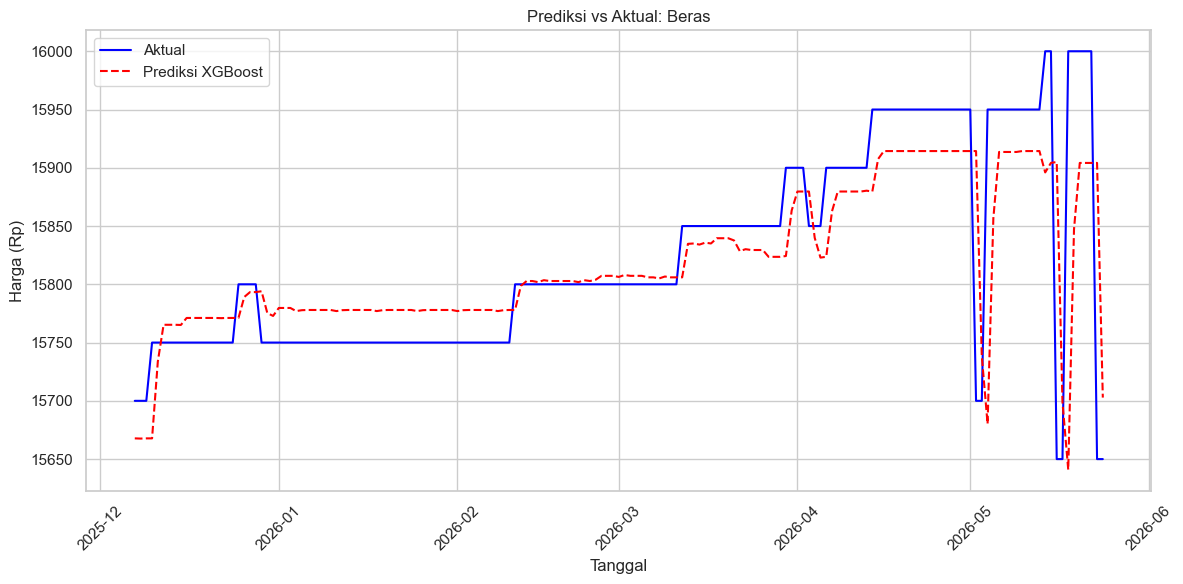

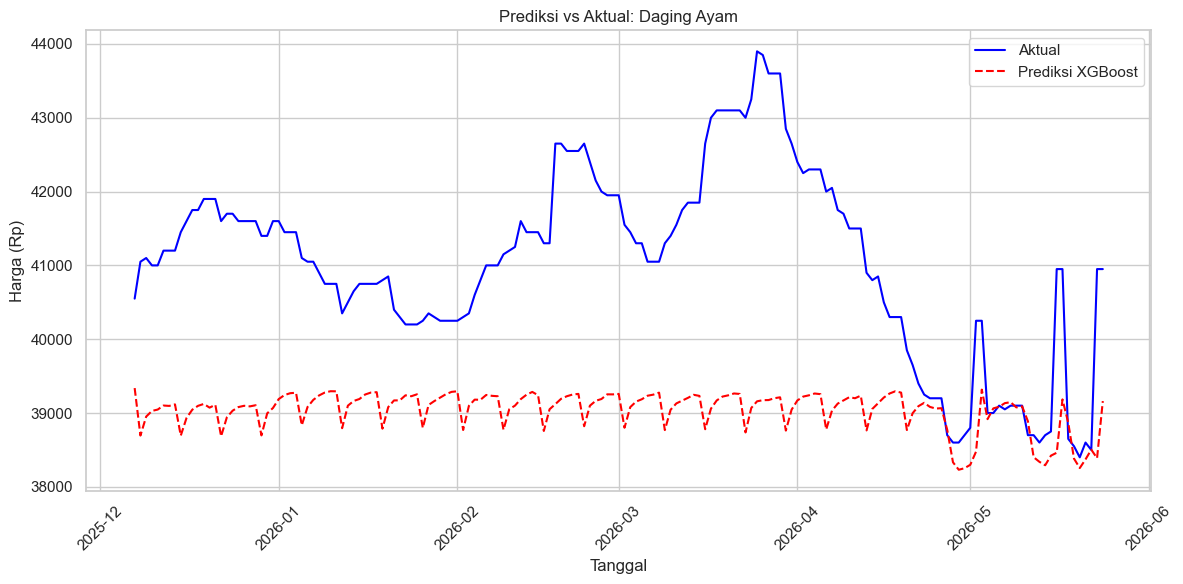

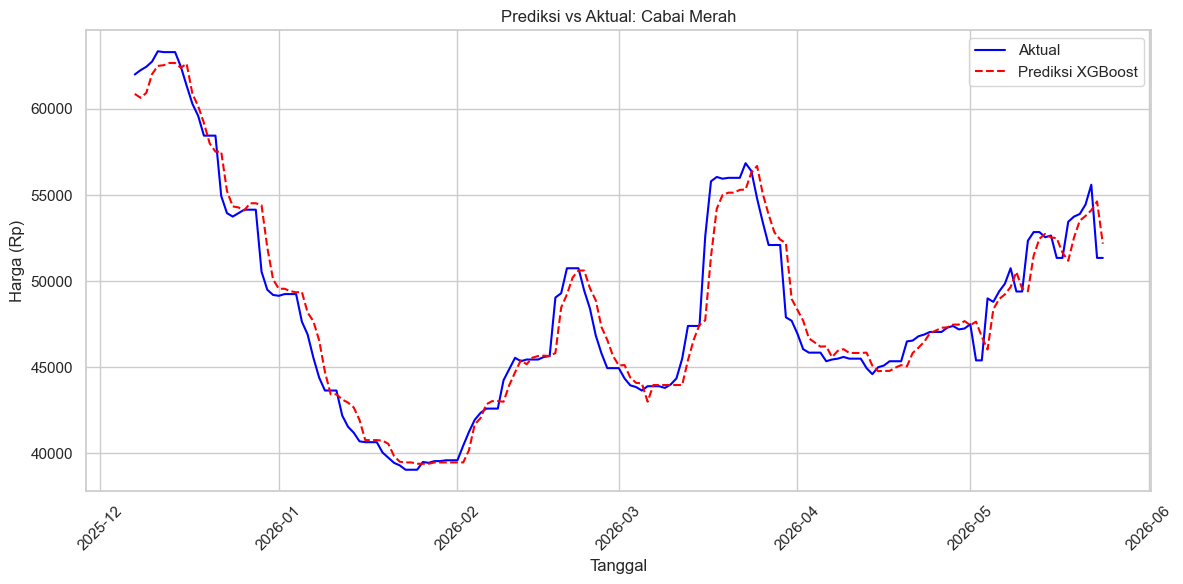

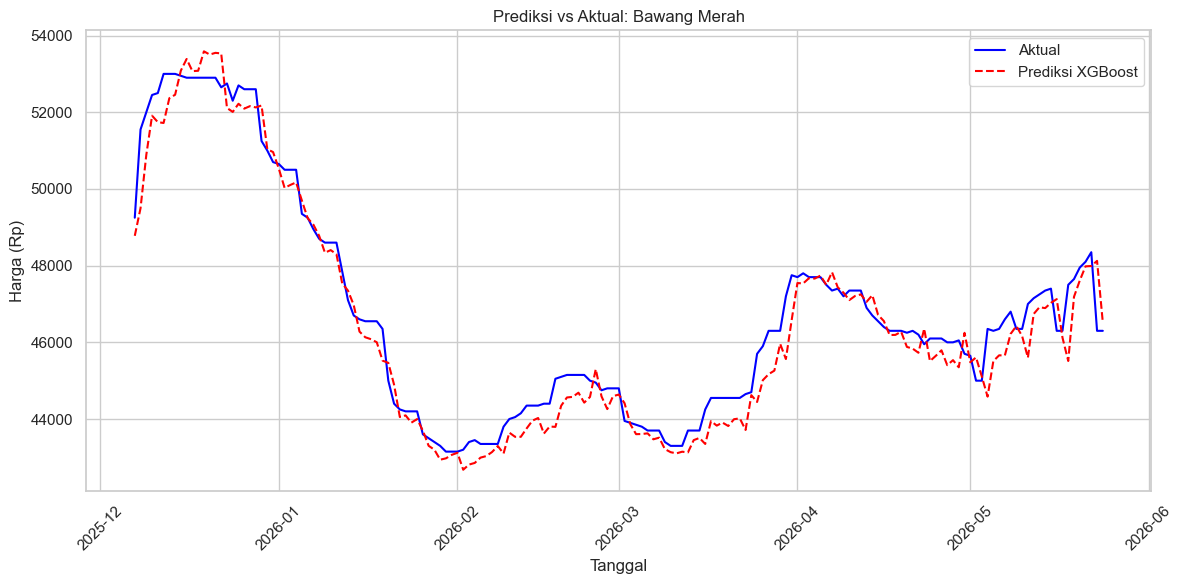

In [11]:
# Visualisasi Kurva Prediksi vs Aktual untuk 4 Komoditas Kunci
key_commodities = ["Beras", "Daging Ayam", "Cabai Merah", "Bawang Merah"]

for cat_name in key_commodities:
    if cat_name in predictions_dict:
        df_pred = predictions_dict[cat_name]
        
        plt.figure(figsize=(12, 6))
        plt.plot(df_pred.index, df_pred["Price"], label="Aktual", color="blue", linewidth=1.5)
        plt.plot(df_pred.index, df_pred["xgboost_pred"], label="Prediksi XGBoost", color="red", linestyle="--", linewidth=1.5)
        
        plt.title(f"Prediksi vs Aktual: {cat_name}")
        plt.xlabel("Tanggal")
        plt.ylabel("Harga (Rp)")
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Data untuk {cat_name} tidak ditemukan")

## Kesimpulan Analisis Eksplorasi XGBoost
Berdasarkan hasil pemodelan deret waktu menggunakan XGBoost pada komoditas pangan nasional:
1. **Pentingnya Feature Engineering**: Pembuatan fitur lag dan datetime terbukti krusial untuk memberikan konteks temporal pada model ensemble tree seperti XGBoost yang tidak memiliki pemahaman waktu bawaan.
2. **Kepatuhan Terhadap Best Practices**:
   - Penerapan **shift** sebelum menghitung rolling statistics berhasil menghindari data leakage.
   - Evaluasi menggunakan **TimeSeriesSplit** dan **Temporal Split** (80/20 train/test split secara kronologis) memastikan model diuji pada data masa depan yang sebenarnya tidak pernah terlihat selama pelatihan.
   - Penyetelan hyperparameter dengan GridSearchCV dikombinasikan dengan **early stopping** meminimalkan risiko overfitting terhadap noise data.
3. **Running Notebook**: Silakan jalankan seluruh cell di notebook ini untuk mendapatkan metrik evaluasi aktual serta visualisasi tren harga pangan berbasis XGBoost untuk setiap komoditas.